# 5G QoS Predictor — EDA & Calibration Visualization

This notebook runs the full EDA pipeline on the 5G-NIDD dataset, extracts calibration parameters,
and visualizes per-KPI distributions, correlations, mobility variance, and time-series overviews.

## 0. Imports & Setup

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import yaml

from src.data.eda_nidd import run_eda, compute_correlations
from src.data.argus_loader import ArgusFlowLoader

%matplotlib inline
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.3})

## 1. Run EDA Pipeline

In [2]:
# Run the full EDA pipeline (use nrows=50000 for a quick run)
DATA_DIR = Path("../data/raw/5g_nidd")
CALIBRATION_PATH = DATA_DIR / "calibration_params.yaml"
FIGURES_DIR = Path("../reports/figures")

calibration_params = run_eda(
    data_dir=DATA_DIR,
    calibration_path=CALIBRATION_PATH,
    figures_dir=FIGURES_DIR,
    nrows=50000,
)
print("EDA complete. Keys:", [k for k in calibration_params.keys()])

No valid data for KPI 'jitter_ms' — returning zeros.
✗ latency_ms: vehicular variance (0.0000) < static variance (0.0000) — proxy data limitation
✗ jitter_ms: vehicular variance (nan) < static variance (nan) — proxy data limitation
✗ packet_loss_pct: vehicular variance (3.3119) < static variance (39.3571) — proxy data limitation
✗ reliability_pct: vehicular variance (3.3119) < static variance (39.3571) — proxy data limitation


EDA complete. Keys: ['dl_throughput', 'ul_throughput', 'latency', 'jitter', 'packet_loss', 'reliability', 'active_users', '_correlations', '_mobility_variance']


## 2. Calibration Parameters

In [3]:
# Display calibration parameters as a formatted table
kpi_rows = []
for kpi, stats_dict in calibration_params.items():
    if kpi.startswith("_"):
        continue
    kpi_rows.append({
        "KPI": kpi,
        "Distribution": stats_dict.get("distribution", "\u2014"),
        "Mean": round(stats_dict.get("mean", 0), 4),
        "Std": round(stats_dict.get("std", 0), 4),
        "Median": round(stats_dict.get("median", 0), 4),
        "Min": round(stats_dict.get("min", 0), 4),
        "Max": round(stats_dict.get("max", 0), 4),
    })

df_params = pd.DataFrame(kpi_rows).set_index("KPI")
df_params.style.set_caption("Calibration Parameters from 5G-NIDD").format(precision=4)

,Distribution,Mean,Std,Median,Min,Max
KPI,,,,,,
dl_throughput,lognormal,2.4132,44.7432,0.0157,0.0000,1304.0000
ul_throughput,lognormal,2.4798,42.5841,0.1202,0.0000,944.0000
latency,gamma,0.0004,0.0048,0.0000,0.0000,0.2000
jitter,exponential,0.0000,0.0000,0.0000,0.0000,0.0000
packet_loss,beta,0.3480,3.9188,0.0000,0.0000,62.5000
reliability,normal,99.6520,3.9188,100.0000,37.5000,100.0000
active_users,normal,13.0000,7.7928,14.0000,0.0000,30.0000


## 3. Per-KPI Distributions with Fitted Curves

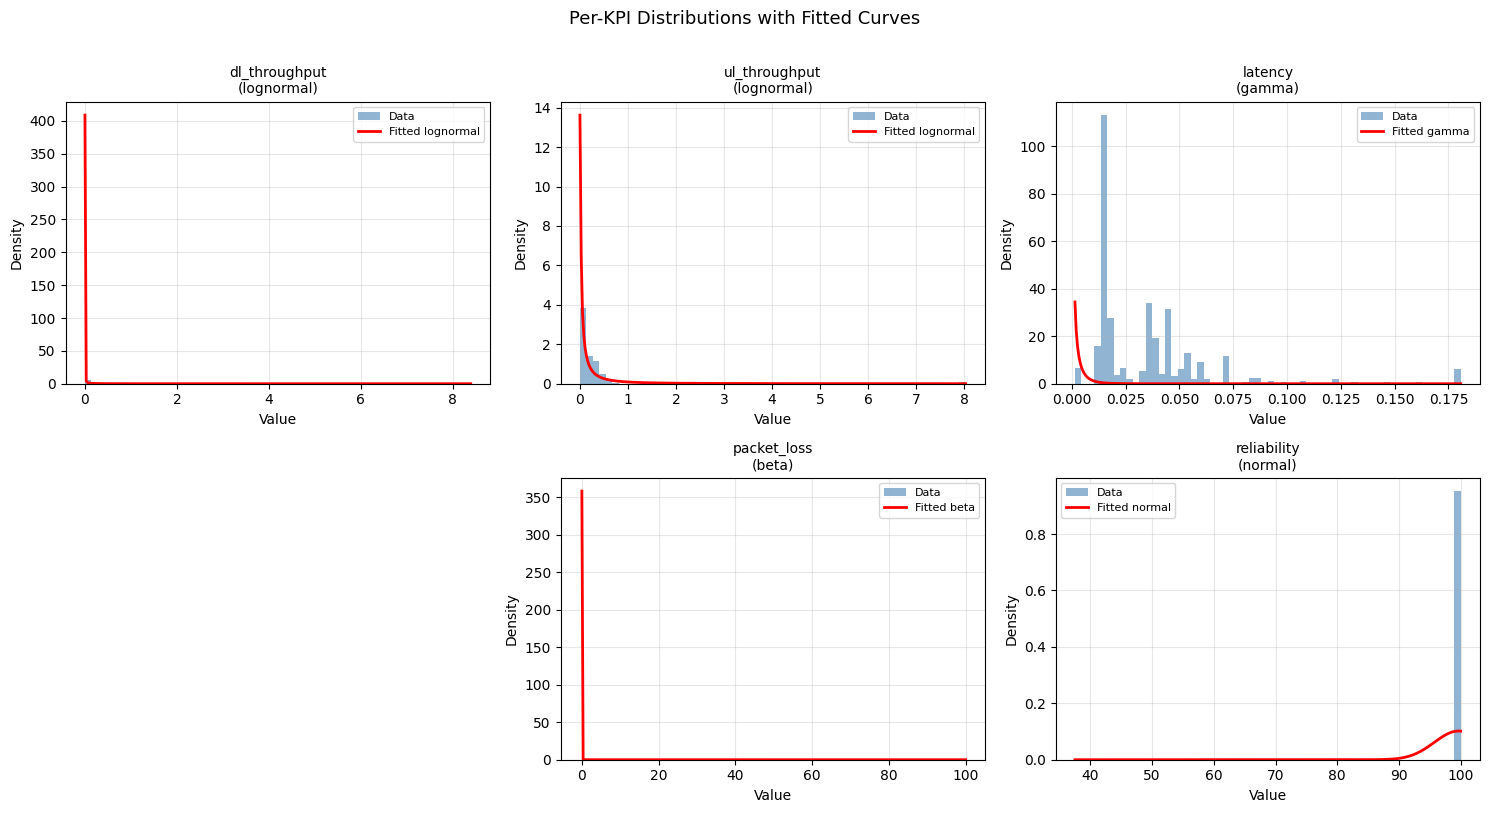

In [4]:
# Load raw data for plotting
loader = ArgusFlowLoader(data_dir=DATA_DIR)
combined = DATA_DIR / "bts_combined" / "BTS1_BTS2_fields_preserved.csv"
file_path = combined if combined.exists() else None

df_flows, df_ts = loader.load_and_process(
    file_path=file_path,
    nrows=50000,
    filter_normal=False,
    aggregate_window="5min",
)

# KPI column mapping: calibration key -> actual column name in df_flows
kpi_col_map = {
    "dl_throughput": "dl_throughput_mbps",
    "ul_throughput": "ul_throughput_mbps",
    "latency": "latency_ms",
    "jitter": "jitter_ms",
    "packet_loss": "packet_loss_pct",
    "reliability": "reliability_pct",
}

public_kpis = {k: v for k, v in calibration_params.items() if not k.startswith("_") and k in kpi_col_map}

n = len(public_kpis)
cols = 3
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
axes_flat = axes.flatten()

for ax, (kpi_key, kpi_stats) in zip(axes_flat, public_kpis.items()):
    col = kpi_col_map[kpi_key]
    if col not in df_flows.columns:
        ax.set_visible(False)
        continue

    data = df_flows[col].dropna()
    data = data[data > 0] if kpi_stats["distribution"] in ("lognormal", "gamma", "exponential") else data
    if len(data) == 0:
        ax.set_visible(False)
        continue

    # Histogram (density=True so PDF overlay works)
    ax.hist(data.clip(upper=data.quantile(0.99)), bins=60, density=True,
            alpha=0.6, color="steelblue", edgecolor="none", label="Data")

    # Fitted distribution curve
    x = np.linspace(data.clip(upper=data.quantile(0.99)).min(),
                    data.clip(upper=data.quantile(0.99)).max(), 300)
    dist_name = kpi_stats["distribution"]
    fp = kpi_stats.get("fit_params", {})

    try:
        if dist_name == "lognormal" and fp:
            pdf = stats.lognorm.pdf(x, s=fp["s"], loc=fp.get("loc", 0), scale=fp["scale"])
            ax.plot(x, pdf, "r-", lw=2, label=f"Fitted {dist_name}")
        elif dist_name == "gamma" and fp:
            pdf = stats.gamma.pdf(x, a=fp["a"], loc=fp.get("loc", 0), scale=fp["scale"])
            ax.plot(x, pdf, "r-", lw=2, label=f"Fitted {dist_name}")
        elif dist_name == "exponential" and fp:
            pdf = stats.expon.pdf(x, loc=fp.get("loc", 0), scale=fp["scale"])
            ax.plot(x, pdf, "r-", lw=2, label=f"Fitted {dist_name}")
        elif dist_name == "beta" and fp:
            # packet_loss is 0-100, beta is 0-1
            x_norm = np.linspace(1e-6, 1 - 1e-6, 300)
            pdf = stats.beta.pdf(x_norm, a=fp["a"], b=fp["b"])
            ax.plot(x_norm * 100, pdf / 100, "r-", lw=2, label=f"Fitted {dist_name}")
        elif dist_name == "normal":
            mu, sigma = kpi_stats["mean"], kpi_stats["std"]
            if sigma > 0:
                pdf = stats.norm.pdf(x, loc=mu, scale=sigma)
                ax.plot(x, pdf, "r-", lw=2, label=f"Fitted {dist_name}")
    except Exception:
        pass

    ax.set_title(f"{kpi_key}\n({dist_name})", fontsize=10)
    ax.set_xlabel("Value")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

for ax in axes_flat[n:]:
    ax.set_visible(False)

fig.suptitle("Per-KPI Distributions with Fitted Curves", fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

## 4. Pearson Correlation Heatmap

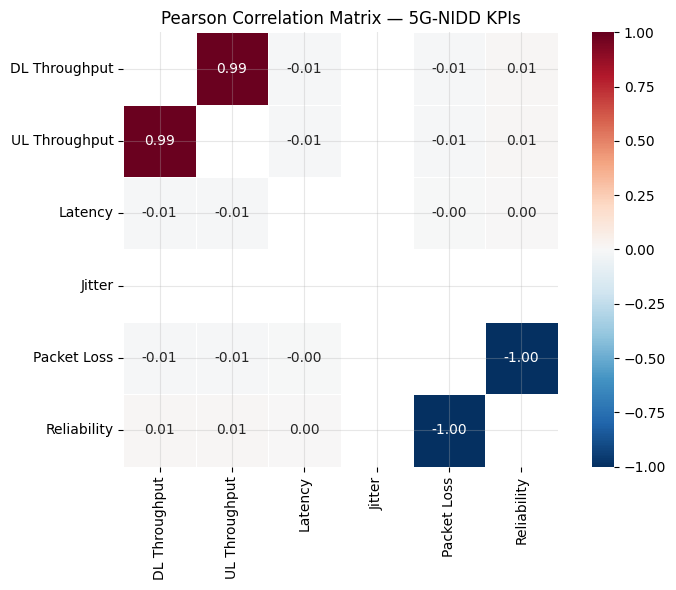

In [5]:
# Pearson correlation heatmap
corr_data = calibration_params.get("_correlations", {})

rename = {
    "dl_throughput_mbps": "DL Throughput",
    "ul_throughput_mbps": "UL Throughput",
    "latency_ms": "Latency",
    "jitter_ms": "Jitter",
    "packet_loss_pct": "Packet Loss",
    "reliability_pct": "Reliability",
}

if corr_data:
    corr_df = pd.DataFrame(corr_data)
    corr_df = corr_df.rename(index=rename, columns=rename)

    fig, ax = plt.subplots(figsize=(8, 6))
    mask = np.zeros_like(corr_df.values, dtype=bool)
    np.fill_diagonal(mask, True)
    sns.heatmap(
        corr_df,
        annot=True,
        fmt=".2f",
        cmap="RdBu_r",
        center=0,
        vmin=-1,
        vmax=1,
        mask=mask,
        ax=ax,
        linewidths=0.5,
        square=True,
    )
    ax.set_title("Pearson Correlation Matrix \u2014 5G-NIDD KPIs", fontsize=12)
    fig.tight_layout()
    plt.show()
else:
    # Recompute from loaded data if not in calibration_params
    kpi_cols_available = [c for c in ["dl_throughput_mbps", "ul_throughput_mbps",
                                       "latency_ms", "jitter_ms", "packet_loss_pct",
                                       "reliability_pct"] if c in df_flows.columns]
    if kpi_cols_available:
        corr_df = df_flows[kpi_cols_available].corr()
        corr_df = corr_df.rename(index=rename, columns=rename)
        fig, ax = plt.subplots(figsize=(8, 6))
        sns.heatmap(corr_df, annot=True, fmt=".2f", cmap="RdBu_r",
                    center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5, square=True)
        ax.set_title("Pearson Correlation Matrix \u2014 5G-NIDD KPIs", fontsize=12)
        fig.tight_layout()
        plt.show()

## 5. Mobility Scenario Variance

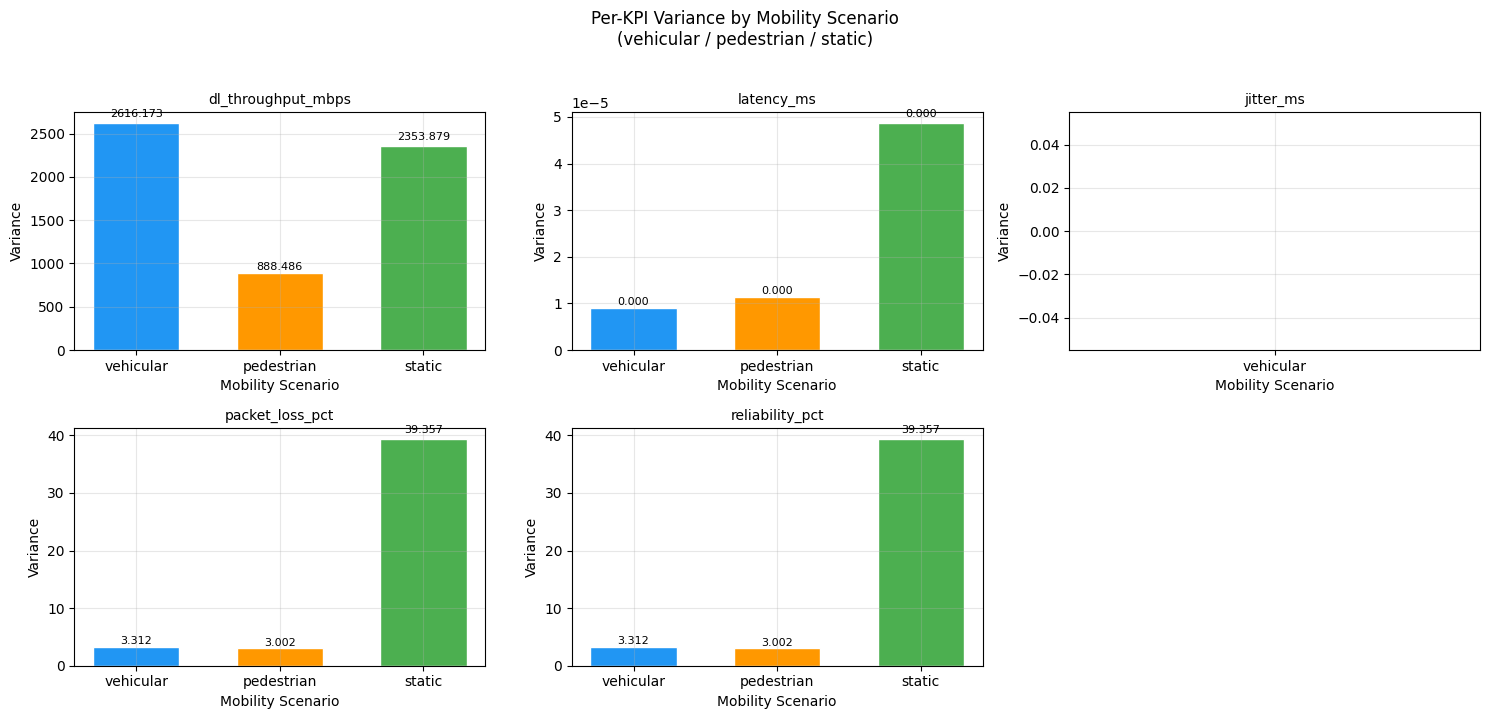

In [6]:
# Per-mobility-scenario variance bar charts
mobility_var = calibration_params.get("_mobility_variance", {})

if mobility_var:
    scenarios = list(mobility_var.keys())
    kpis = list(next(iter(mobility_var.values())).keys())

    n_kpis = len(kpis)
    cols = 3
    rows = (n_kpis + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 3.5 * rows))
    axes_flat = axes.flatten() if hasattr(axes, "flatten") else [axes]

    colors = ["#2196F3", "#FF9800", "#4CAF50"]

    for ax, kpi in zip(axes_flat, kpis):
        variances = [mobility_var[s].get(kpi, 0.0) for s in scenarios]
        bars = ax.bar(scenarios, variances, color=colors, edgecolor="white", width=0.6)
        ax.set_title(kpi, fontsize=10)
        ax.set_ylabel("Variance")
        ax.set_xlabel("Mobility Scenario")
        # Annotate bars
        for bar, val in zip(bars, variances):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.02,
                    f"{val:.3f}", ha="center", va="bottom", fontsize=8)

    for ax in axes_flat[n_kpis:]:
        ax.set_visible(False)

    fig.suptitle("Per-KPI Variance by Mobility Scenario\n(vehicular / pedestrian / static)",
                 fontsize=12, y=1.02)
    fig.tight_layout()
    plt.show()
else:
    print("No mobility variance data available in calibration_params.")

## 6. Time-Series Overview

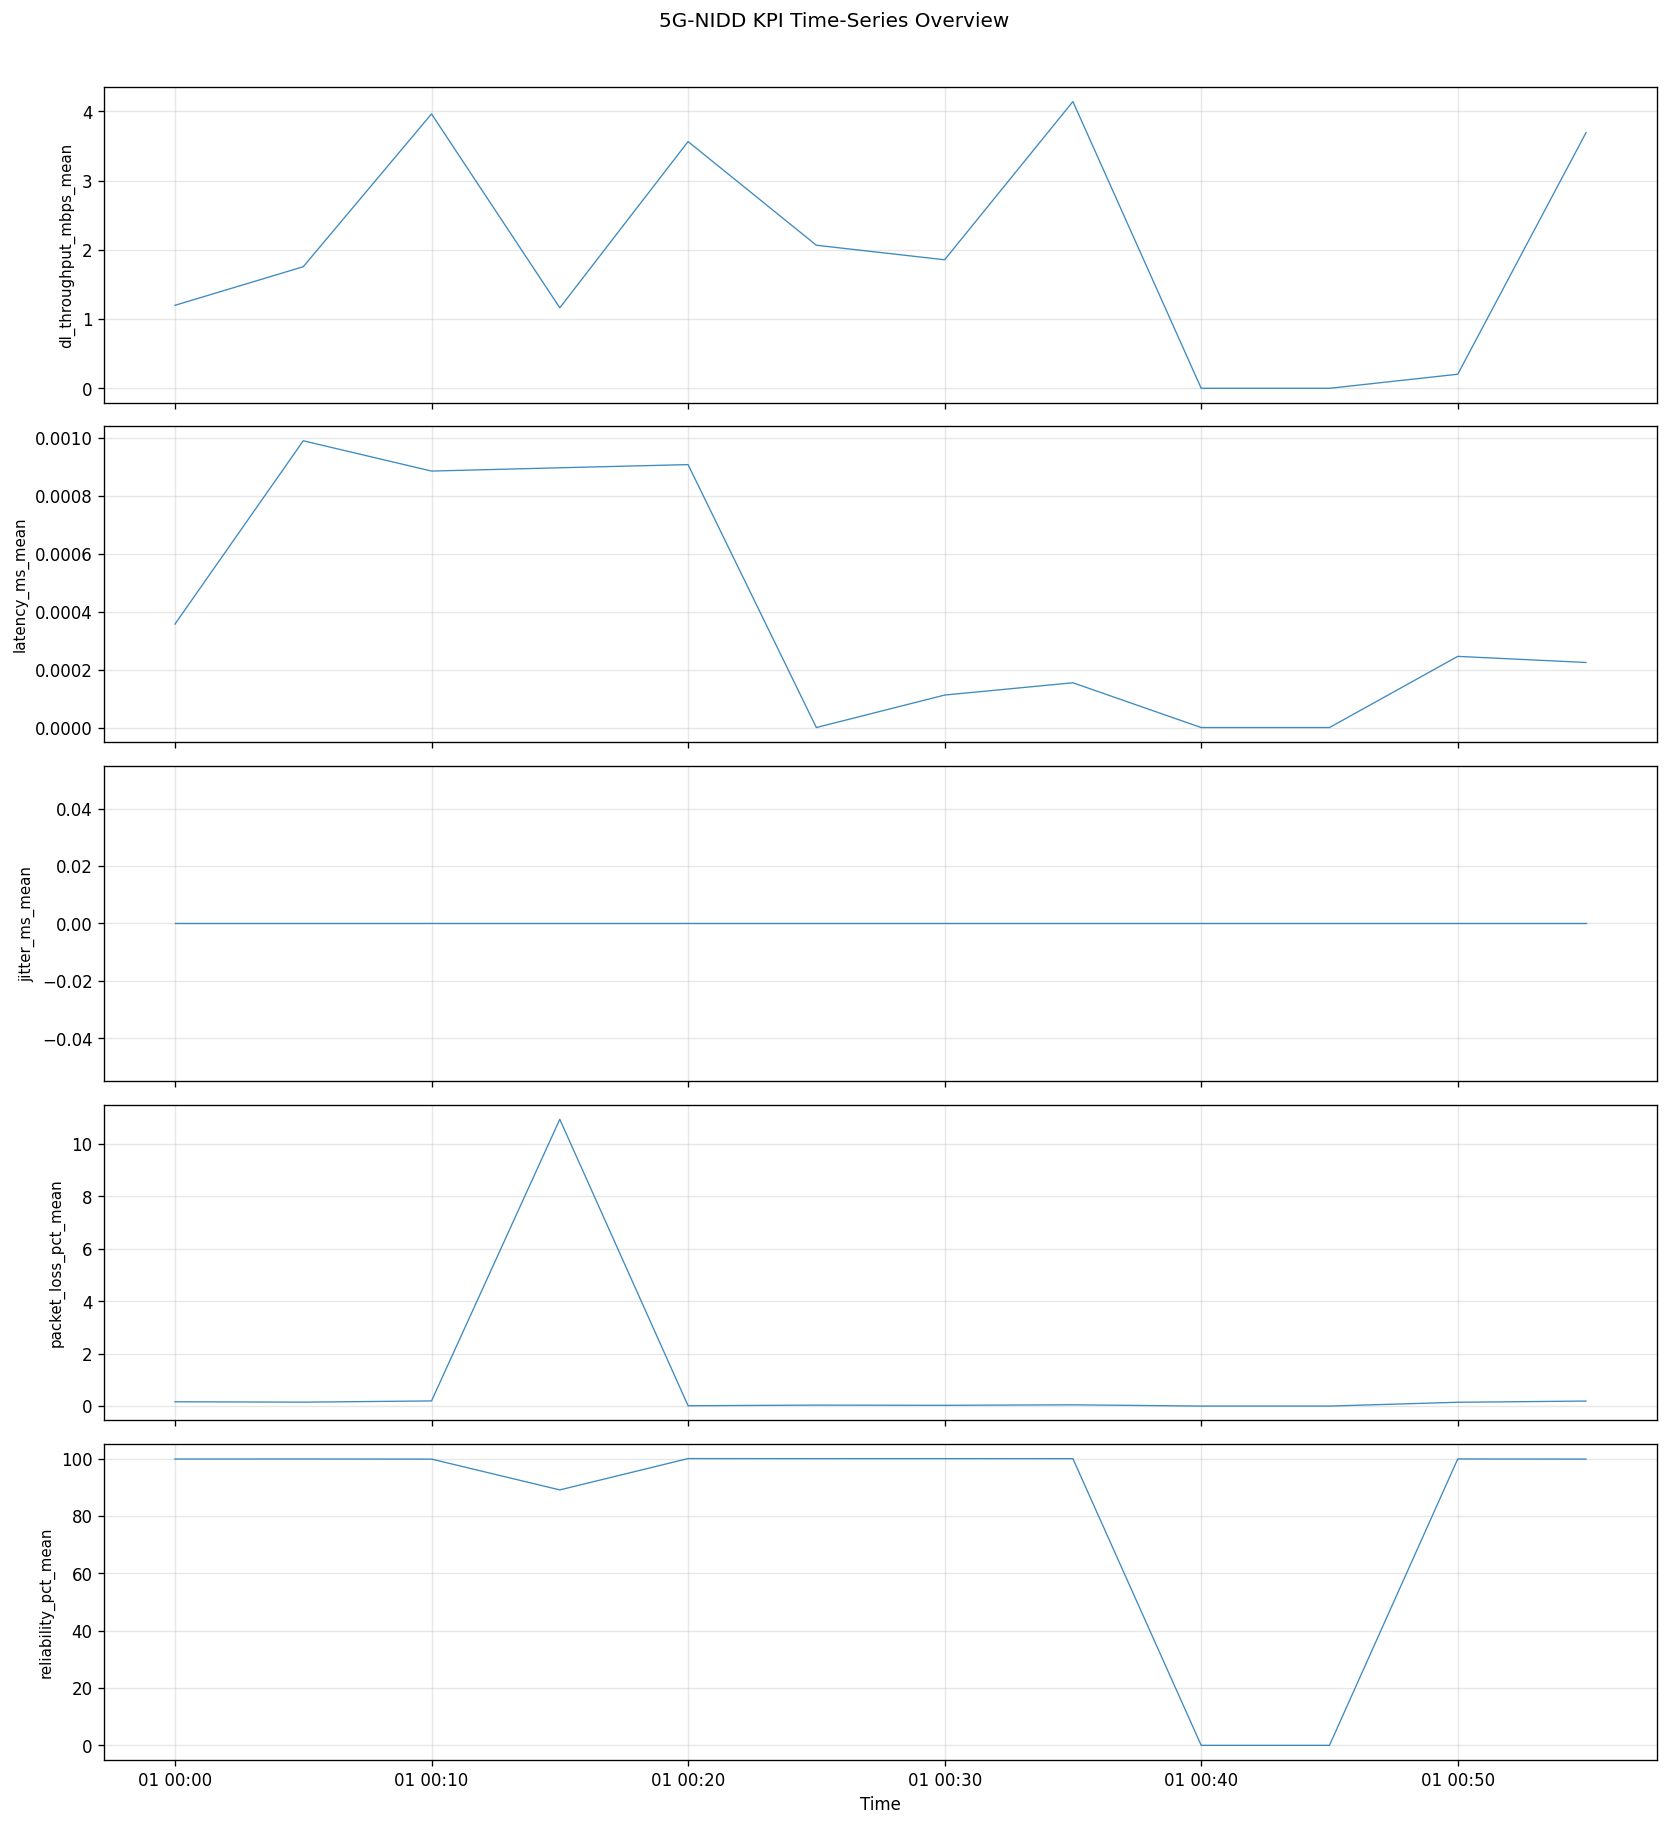

In [7]:
# Render the time-series overview plot inline
from IPython.display import Image, display

ts_plot = FIGURES_DIR / "timeseries_overview.png"
if ts_plot.exists():
    display(Image(filename=str(ts_plot), width=900))
else:
    # Plot directly from df_ts
    kpi_ts_cols = [c for c in df_ts.columns
                   if any(c.startswith(k) for k in ["dl_throughput", "latency", "packet_loss",
                                                     "reliability", "active_users"])][:5]
    if kpi_ts_cols:
        fig, axes = plt.subplots(len(kpi_ts_cols), 1, figsize=(14, 3 * len(kpi_ts_cols)), sharex=True)
        if len(kpi_ts_cols) == 1:
            axes = [axes]
        x = df_ts["timestamp"] if "timestamp" in df_ts.columns else df_ts.index
        for ax, col in zip(axes, kpi_ts_cols):
            ax.plot(x, df_ts[col], linewidth=0.8, alpha=0.85)
            ax.set_ylabel(col, fontsize=9)
        axes[-1].set_xlabel("Time")
        fig.suptitle("5G-NIDD KPI Time-Series Overview", fontsize=12)
        fig.tight_layout()
        plt.show()
    else:
        print("No time-series data available to plot.")